# Trial modes on the proficient syllables (02-10-2026)

The current trial-mode pipeline — `Functions/trial_modes.py`, as used in `neuromodulators/1_trial_modes.ipynb` (one-hot syllables per bin → PCA → UMAP → KDE → watershed) — run on the **proficient** syllable file the current LDA is built from, `clustering/data_files/8_k_10_bin_syllables_02-10-2026`.

Differences from the older proficient trial modes (`clustering/data_files/{12,17,22}_trial_waterclust`, from `clustering_trial_syllables_watershed.ipynb`):
* newer syllables: 'uniform' paw states (vigor-numbered), both paws + whisk + lick;
* trials come out in chronological order; KDE grid bounds from the data; KDE fitted on a 50k subsample;
* the stored paw digits carry the 19Aug2026 relabelling, which is **undone here before clustering** (`ps.paw_codes`), so `ref_paw=1` drops uniform state 1 (slow) and the plots use the uniform palette.

Outputs (cached; `RECOMPUTE=True` to refit) in `3_trial_modes/trial_modes_8_k_10_bin_syllables_02-10-2026/`:
`trials.pqt` (one row per trial: sample, session, mouse_name, trial_id, trial_cluster, embedding_x/y) and `fit.pkl` (PCA, KDE, watershed labels, params; not the UMAP reducer).

In [1]:
import sys, pathlib, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'Functions' / 'trial_modes.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'paper-individuality'))
from Functions import trial_modes as tm
import paper_style as ps
ps.use('paper')
ps.use_paw_states('uniform')

PI = REPO / 'paper-individuality'
SYLLABLE_FILE = PI / 'clustering' / 'data_files' / '8_k_10_bin_syllables_02-10-2026'
META_FILE = PI / 'data' / 'session_trial_meta_10-07-2026'     # reaction / elongation (244 sessions)
OUT = PI / '3_trial_modes' / f'trial_modes_{SYLLABLE_FILE.name}'

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters (defaults = the original notebook, as in the NM run)

In [2]:
PARAMS = dict(
    encoding='factored',     # paw one-hot (minus ref_paw) + whisk + lick per bin; 'onehot' = 32 codes per bin
    ref_paw=1,               # uniform state 1 (slow) is the dropped reference
    n_pca=None,              # None = all components (PCA is then only a rotation)
    random_state=42,
    res=150,
    kde_max_points=50_000,
    threshold_pct=60,
    min_distance=10,
    footprint_radius=2,
)
RECOMPUTE = False

In [3]:
syllables = pd.read_parquet(SYLLABLE_FILE)
# undo the stored 19Aug2026 paw relabelling -> uniform (vigor) numbering
codes = ps.paw_codes(np.stack(syllables['binned_sequence'].to_numpy()).astype(float))
syllables['binned_sequence'] = list(codes)

if (OUT / 'trials.pqt').exists() and not RECOMPUTE:
    trials = pd.read_parquet(OUT / 'trials.pqt')
    for e in tm.EPOCHS:
        trials[e] = trials[e].map(np.asarray)
    with open(OUT / 'fit.pkl', 'rb') as f:
        res = pickle.load(f)
    assert res['params'] == {**res['params'], **PARAMS}, 'cached fit used other PARAMS: set RECOMPUTE = True'
    print('loaded cached fit')
else:
    trials, res = tm.cluster_trials(syllables, **PARAMS)
    OUT.mkdir(exist_ok=True)
    trials.to_parquet(OUT / 'trials.pqt')
    with open(OUT / 'fit.pkl', 'wb') as f:   # the UMAP reducer holds the whole training matrix: not saved
        pickle.dump({k: v for k, v in res.items() if k not in ('reducer', 'embedding')}, f)
n_modes = int(trials['trial_cluster'].max())
no_emb = trials['embedding_x'].isna()
print(f"{len(trials)} trials with all 4 epochs, {trials['session'].nunique()} sessions, "
      f"{trials['mouse_name'].nunique()} mice, {n_modes} modes")
print(f"{no_emb.mean():.1%} not embedded (a NaN syllable bin), "
      f"{(~no_emb & trials['trial_cluster'].isna()).mean():.1%} embedded but on the KDE background")

loaded cached fit
206879 trials with all 4 epochs, 332 sessions, 101 mice, 17 modes
3.6% not embedded (a NaN syllable bin), 2.2% embedded but on the KDE background


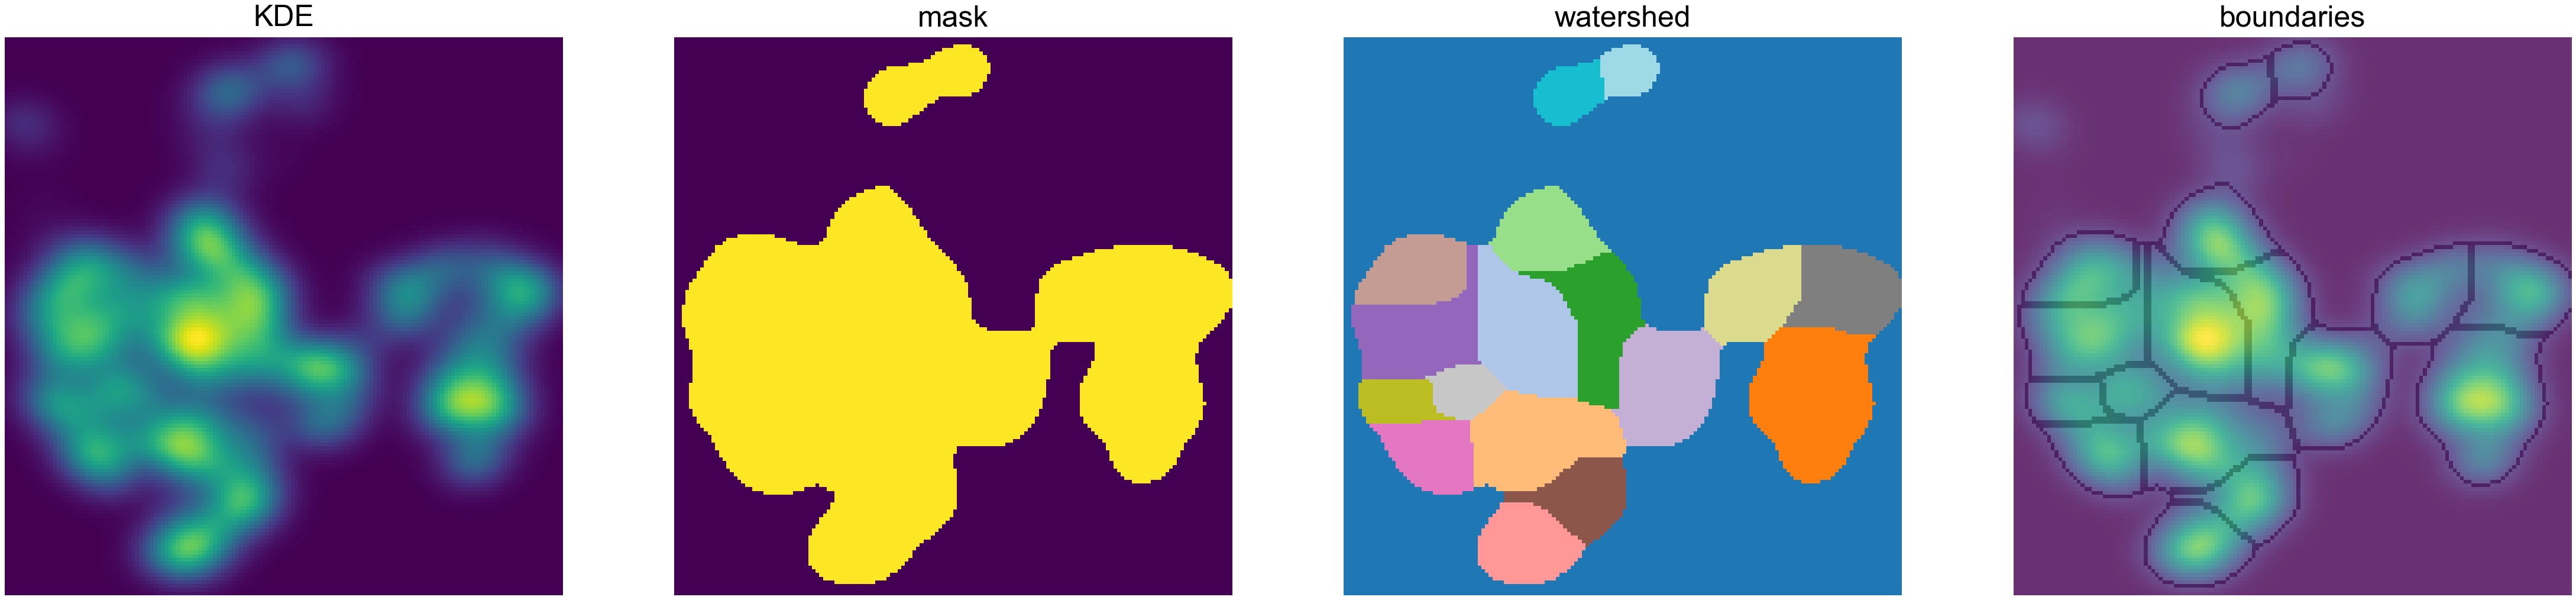

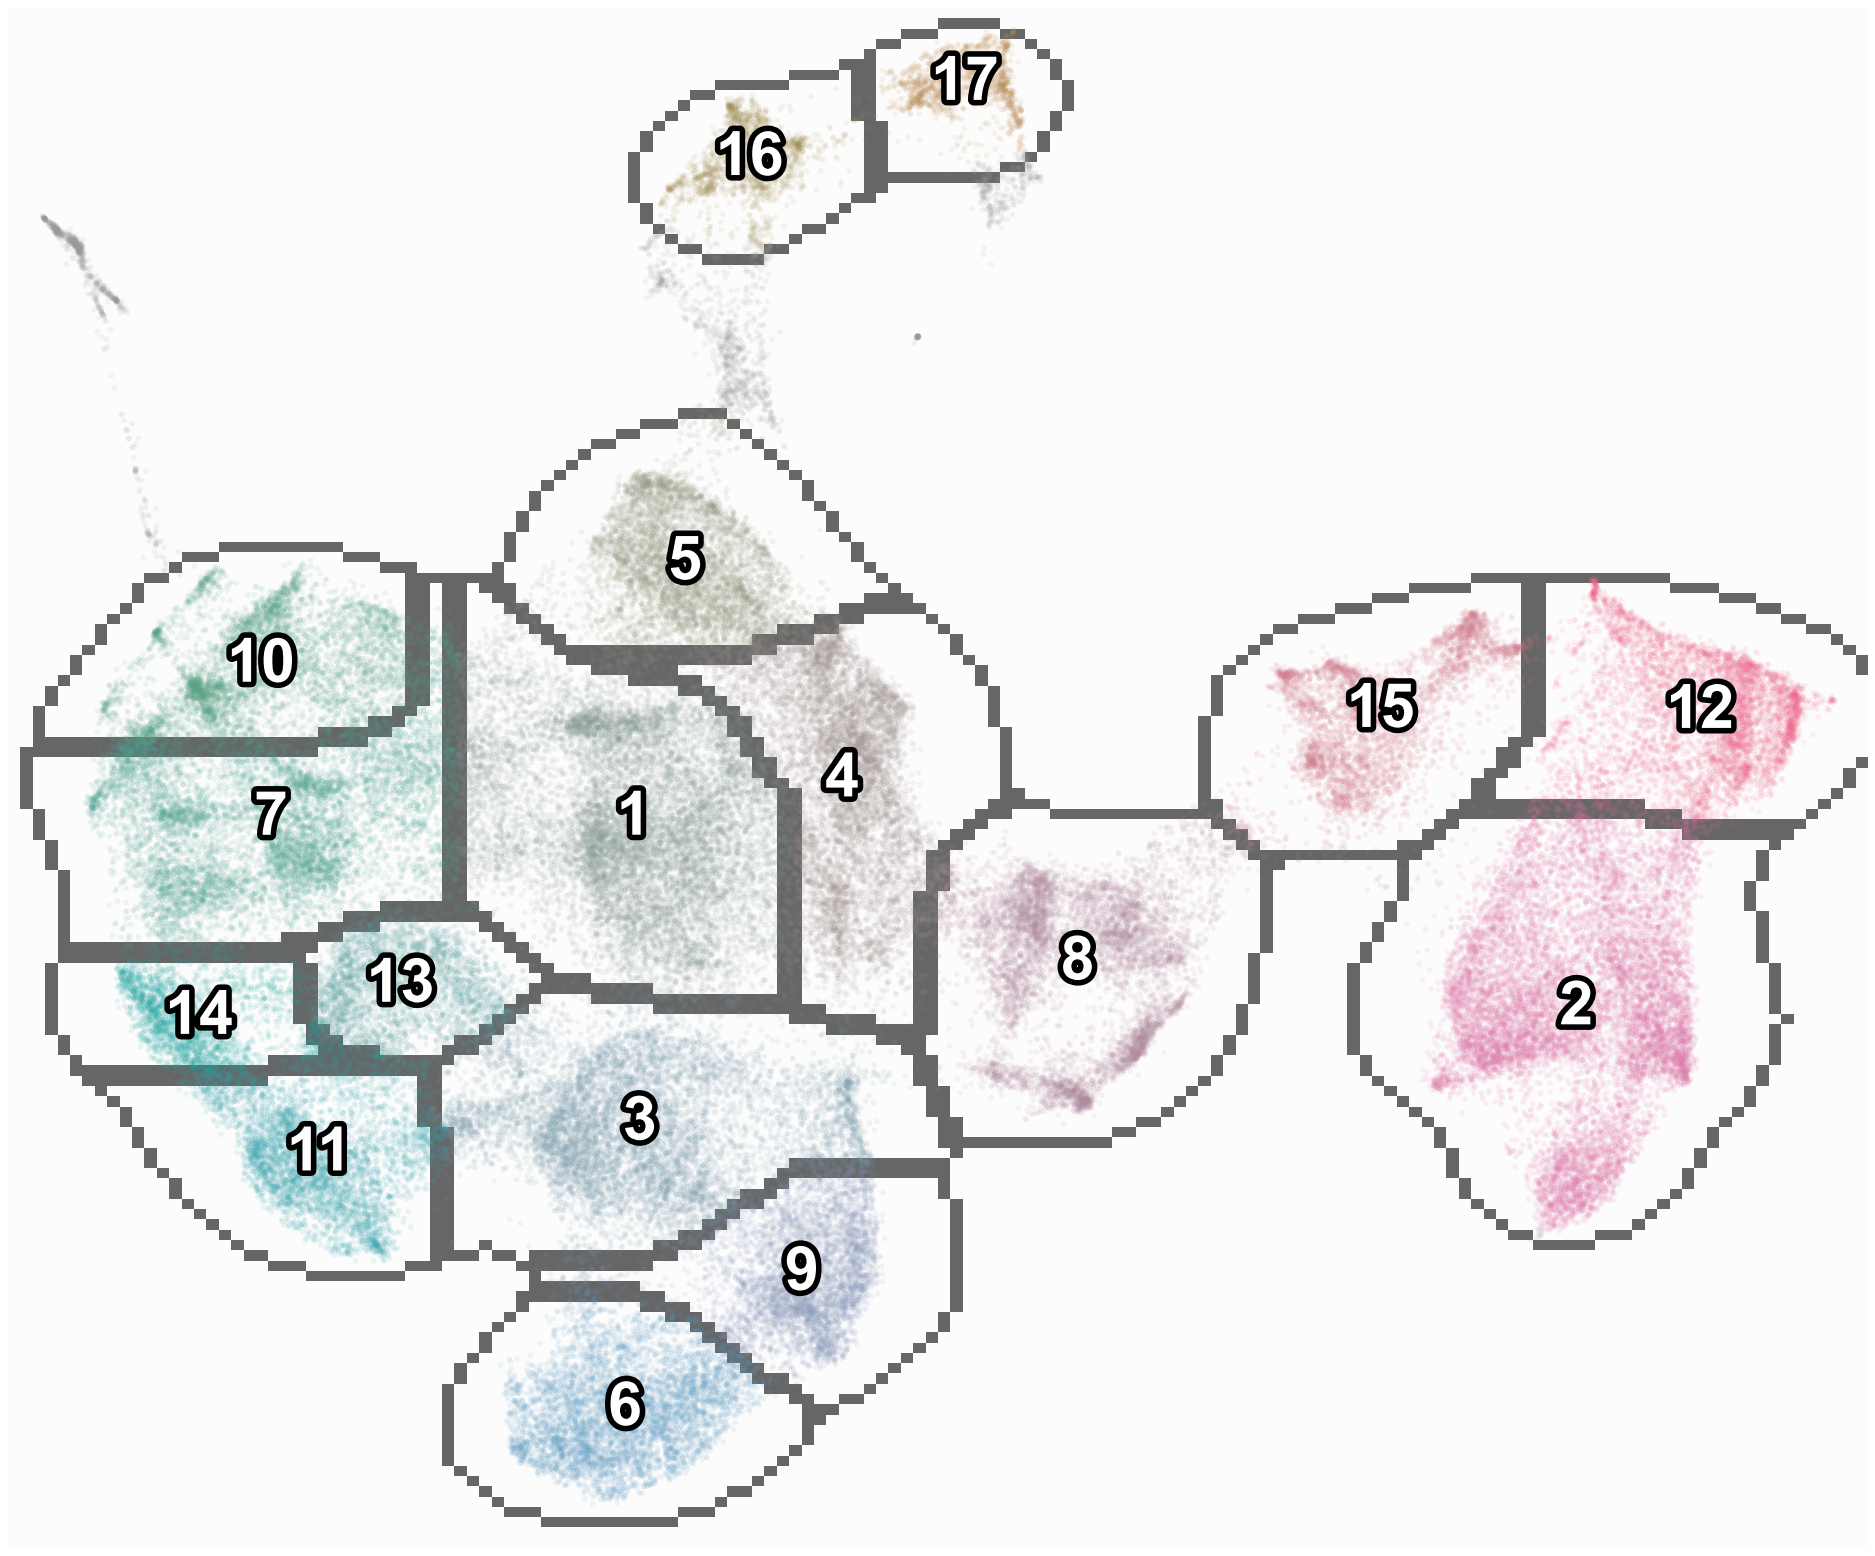

In [4]:
# one colour per mode from its UMAP position (CIELAB a*/b* plane at fixed lightness):
# nearby modes get similar colours. Used in every figure below.
MODE_COLORS = tm.umap_colors(trials)
tm.plot_watershed(res);
tm.plot_clusters(trials, res, colors=MODE_COLORS);

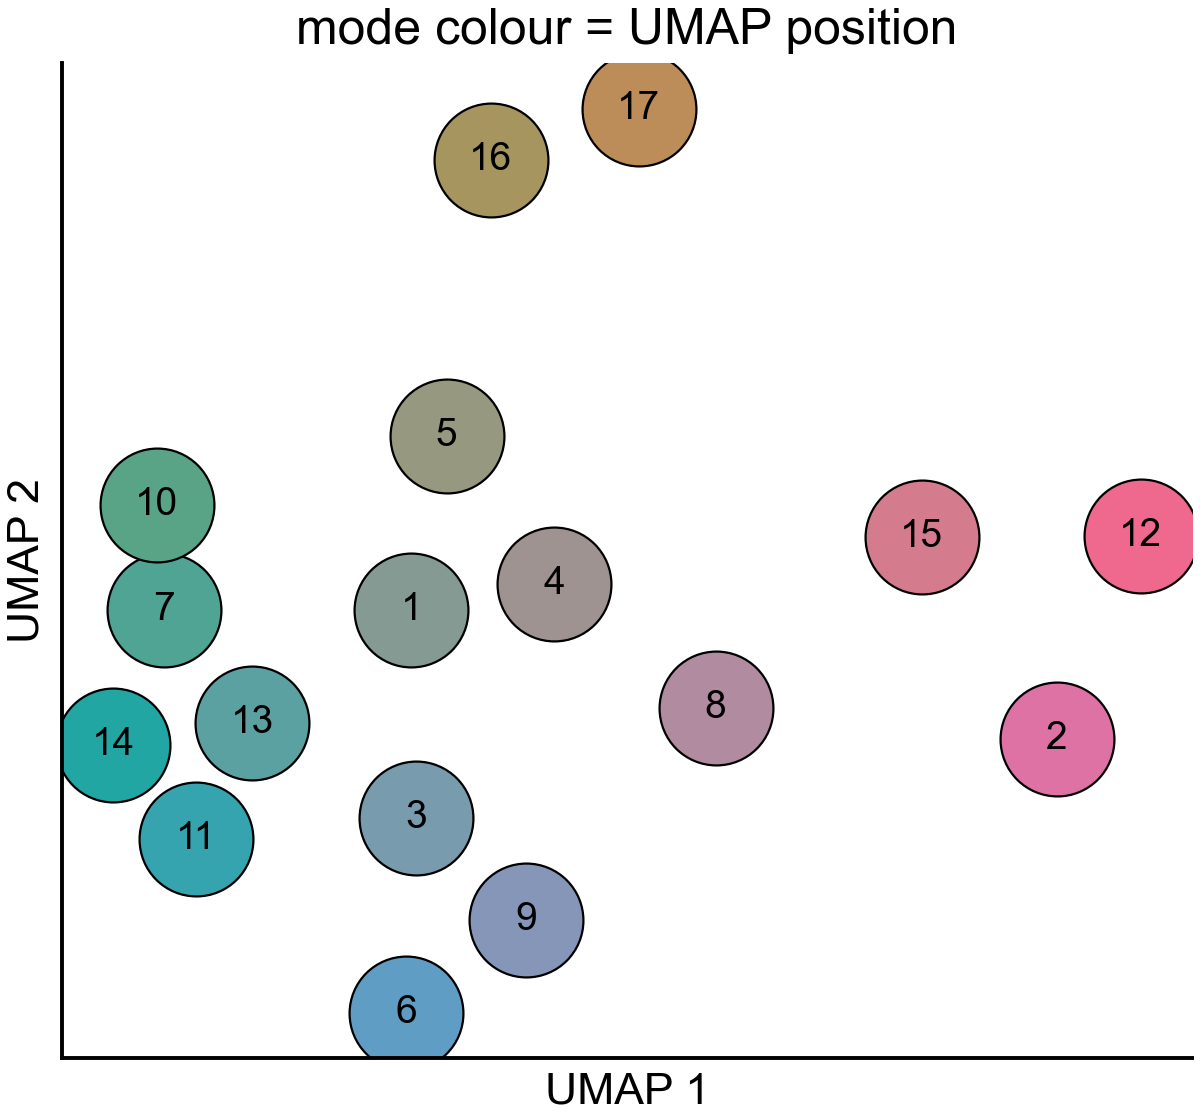

In [5]:
# colour key: each mode at its UMAP centroid, in its colour
cen = trials.dropna(subset=['trial_cluster']).groupby('trial_cluster')[['embedding_x', 'embedding_y']].mean()
fig, ax = plt.subplots(figsize=(3.2, 3))
for k, (x, y) in cen.iterrows():
    ax.scatter(x, y, s=420, color=MODE_COLORS[k], edgecolor='k', lw=0.4)
    ax.text(x, y, str(int(k)), ha='center', va='center', fontsize=7)
ax.set(xlabel='UMAP 1', ylabel='UMAP 2', title='mode colour = UMAP position')
ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

## Trial variables

In [6]:
parts = trials['trial_type'].str.split(expand=True)
trials['correct'] = (parts[0] == 'correct').astype(float)
trials['contrast'] = parts[1].astype(float)
trials['block'] = parts[2].astype(float)
trials['no_go'] = parts[3] == 'no_go'
meta = pd.read_parquet(META_FILE, columns=['session', 'trial_id', 'reaction', 'elongation'])
trials = trials.merge(meta, on=['session', 'trial_id'], how='left')
print(f"trials with reaction time: {trials['reaction'].notna().mean():.1%}")

trials with reaction time: 72.6%


## What each mode looks like
Syllable composition per bin (pale-still top → dark-vigorous), whisk / lick below; then accuracy and median reaction time by |contrast| (mouse as unit; a mouse contributes to a point only with ≥ `MIN_TRIALS_POINT` trials). Panels are ordered by mode colour (hue around the UMAP centre), so modes that are close in UMAP sit next to each other; the table below the figure is sorted by accuracy. Choice direction is not used (choice labels are mirrored in some files).

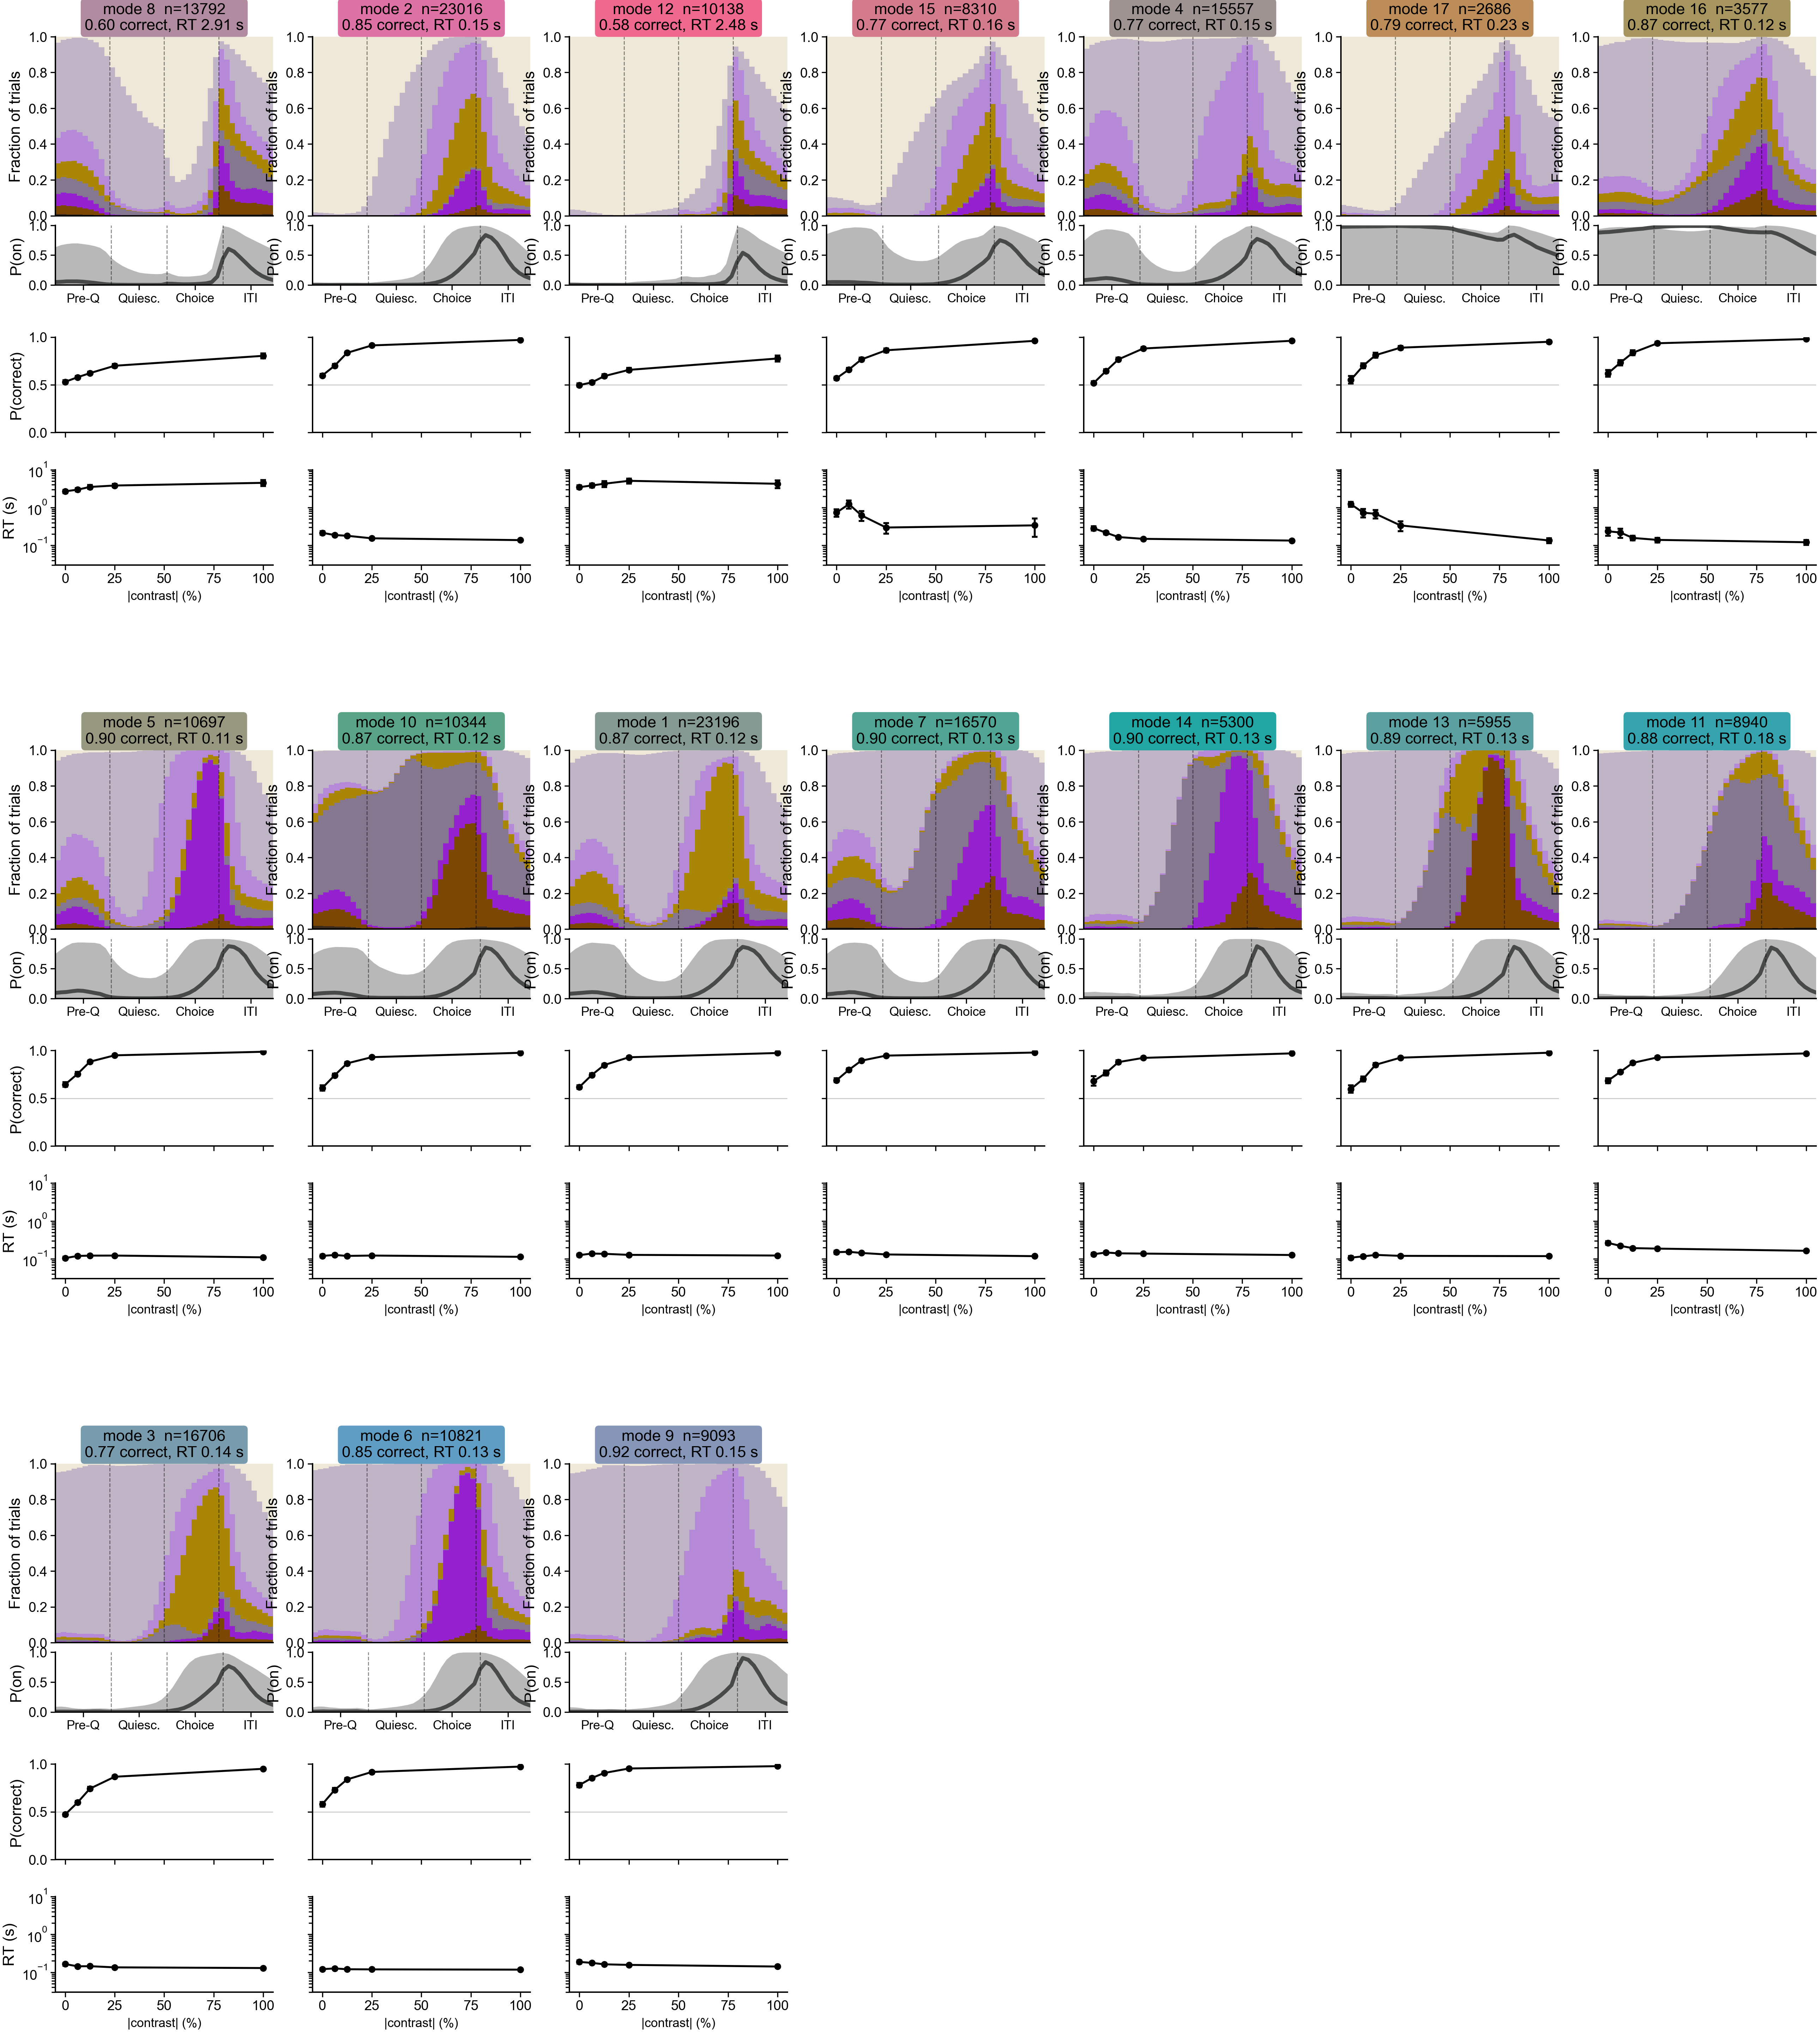

,n,frac_correct,median_reaction,frac_no_go
trial_cluster,,,,
9.0,9093,0.918,0.153,0.000
7.0,16570,0.903,0.126,0.000
5.0,10697,0.901,0.110,0.000
14.0,5300,0.896,0.133,0.000
13.0,5955,0.888,0.127,0.000
11.0,8940,0.878,0.181,0.000
10.0,10344,0.873,0.120,0.000
1.0,23196,0.870,0.119,0.000
16.0,3577,0.867,0.119,0.000


In [7]:
MIN_TRIALS_POINT = 5
mode_summary = (trials.dropna(subset=['trial_cluster']).groupby('trial_cluster')
                .agg(n=('correct', 'size'), frac_correct=('correct', 'mean'),
                     median_reaction=('reaction', 'median'), frac_no_go=('no_go', 'mean')))
# panels follow the colour wheel (UMAP position), so similar-coloured modes sit side by side
mode_order = [int(k) for k in tm.umap_order(trials)]
CONTRASTS = sorted(trials['contrast'].dropna().unique())
# one fixed log RT axis for every mode, so modes are comparable at a glance
RT_LIM = (trials['reaction'].clip(lower=0.03).quantile(0.01), 10)

def by_contrast(d, value, stat):
    pm = (d.groupby(['mouse_name', 'contrast'])[value].agg([stat, 'size'])
          .query('size >= @MIN_TRIALS_POINT')[stat])
    return pm.groupby('contrast').agg(['mean', 'sem'])

ncol = 7
nrow = int(np.ceil(len(mode_order) / ncol))
fig = plt.figure(figsize=(2.3 * ncol, 6.0 * nrow))
outer = fig.add_gridspec(nrow, ncol, hspace=0.35, wspace=0.18)
for i, k in enumerate(mode_order):
    inner = outer[i // ncol, i % ncol].subgridspec(6, 1, height_ratios=[3, 1, 0.55, 1.6, 0.3, 1.6], hspace=0.12)
    ax, ax_wl = fig.add_subplot(inner[0]), fig.add_subplot(inner[1])
    ax_acc, ax_rt = fig.add_subplot(inner[3]), fig.add_subplot(inner[5])
    sub = trials[trials['trial_cluster'] == k]
    _, codes_k = tm.trial_matrix_from_trials(sub)
    ps.syllable_histogram(codes_k, ax=ax); ps.whisk_lick_panel(codes_k, ax=ax_wl)
    for a in (ax, ax_wl):
        ps.epoch_lines(a, codes_k.shape[1])
    m = mode_summary.loc[float(k)] if float(k) in mode_summary.index else mode_summary.loc[k]
    ax.set_title(f"mode {k}  n={int(m['n'])}\n{m['frac_correct']:.2f} correct, RT {m['median_reaction']:.2f} s",
                 fontsize=plt.rcParams['font.size'], color='k',
                 bbox=dict(boxstyle='round,pad=0.25', facecolor=MODE_COLORS[float(k)], edgecolor='none'))
    ax.set_xticks([]); ax_wl.set_xticks([5, 15, 25, 35], ps.EPOCH_SHORT, fontsize=plt.rcParams['font.size'] * .8)
    acc = by_contrast(sub[~sub['no_go']], 'correct', 'mean')
    ax_acc.errorbar(acc.index * 100, acc['mean'], yerr=acc['sem'].fillna(0), color='k', marker='o', ms=2.5, lw=1)
    ax_acc.set_ylim(0, 1); ax_acc.axhline(.5, color='0.8', lw=.5); ax_acc.set_xticklabels([])
    rt = by_contrast(sub.assign(reaction=sub['reaction'].clip(lower=0.03)).dropna(subset=['reaction']), 'reaction', 'median')
    ax_rt.errorbar(rt.index * 100, rt['mean'], yerr=rt['sem'].fillna(0), color='k', marker='o', ms=2.5, lw=1)
    ax_rt.set_yscale('log'); ax_rt.set_ylim(*RT_LIM); ax_rt.set_xlabel('|contrast| (%)', fontsize=plt.rcParams['font.size'] * .8)
    if i % ncol == 0:
        ax_acc.set_ylabel('P(correct)'); ax_rt.set_ylabel('RT (s)')
    else:
        ax_acc.set_yticklabels([]); ax_rt.set_yticklabels([])
        ax_rt.yaxis.set_minor_formatter(plt.NullFormatter())
plt.show()
mode_summary.sort_values('frac_correct', ascending=False).round(3)

## How sensitive is the number of modes to the watershed knobs?
Re-runs only KDE → watershed on the cached embedding (cheap). If the count is flat here it is set upstream, by the KDE bandwidth and the UMAP layout.

In [8]:
emb = trials[['embedding_x', 'embedding_y']].dropna().to_numpy()
rows = []
for thr in [50, 60, 70]:
    for md_ in [5, 8, 10, 15, 20]:
        L = tm.watershed_map(res['Z'], threshold_pct=thr, min_distance=md_)
        lab = tm.assign(emb, L, res['bounds'])
        sizes = pd.Series(lab).value_counts(normalize=True)
        rows.append({'threshold_pct': thr, 'min_distance': md_, 'n_modes': L.max(),
                     'background': np.isnan(lab).mean(), 'smallest_mode': sizes.min()})
pd.DataFrame(rows).pivot(index='min_distance', columns='threshold_pct', values='n_modes')

threshold_pct,50,60,70
min_distance,,,
5,18,17,17
8,18,17,17
10,18,17,16
15,13,13,12
20,10,10,9


## Mode usage per mouse

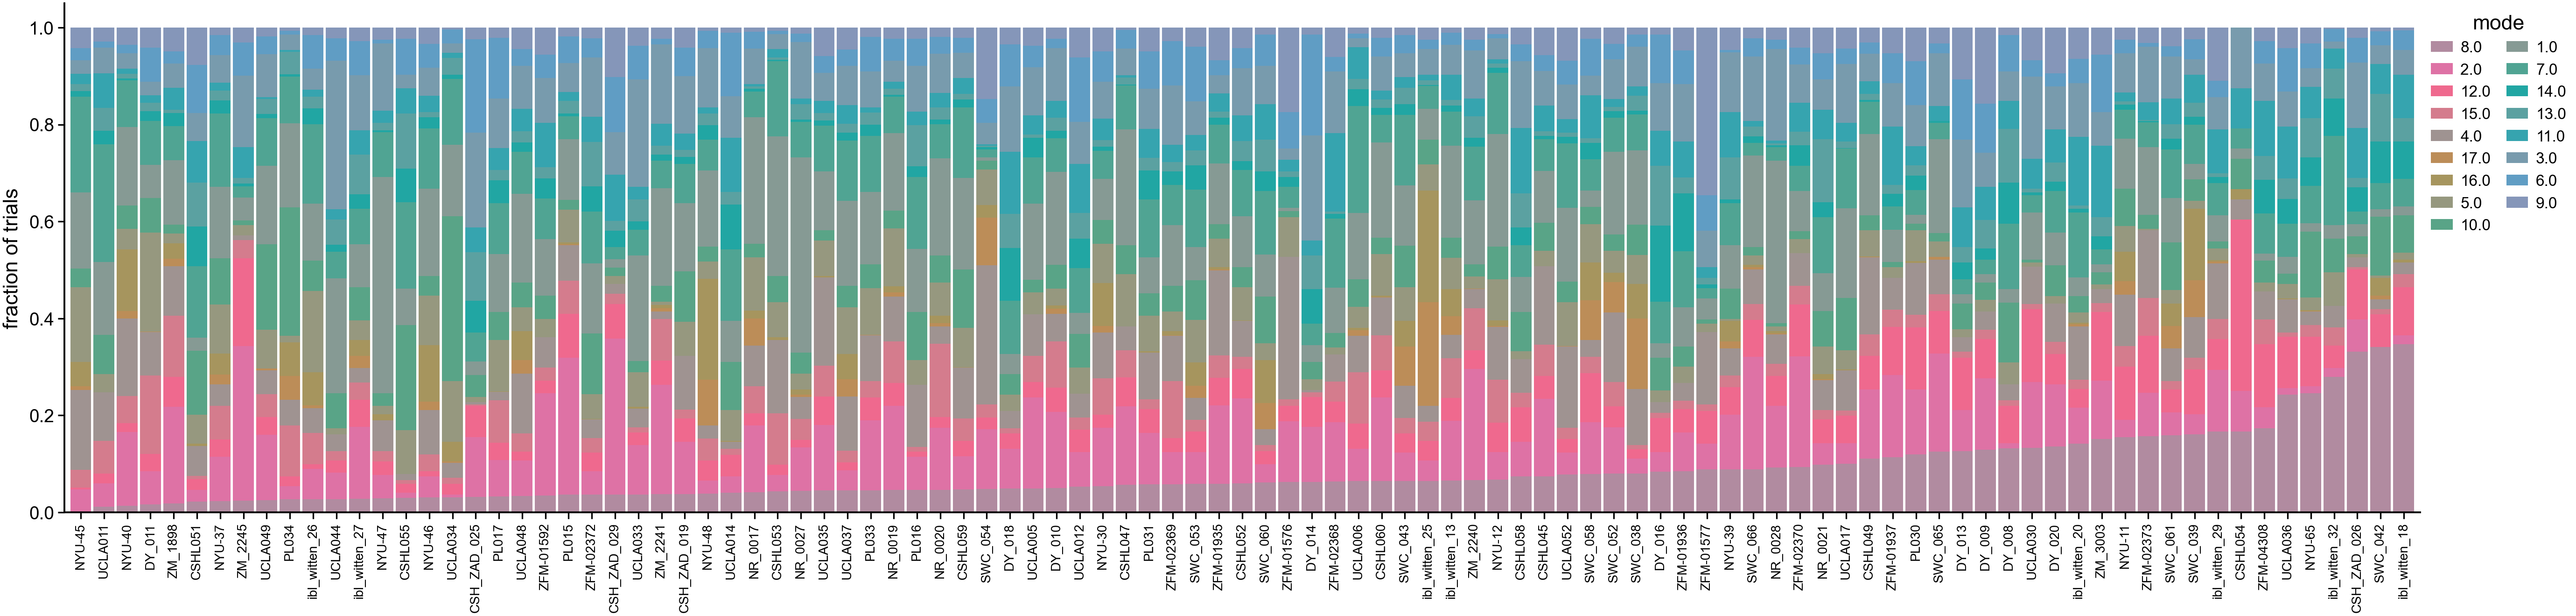

In [9]:
usage = (trials.dropna(subset=['trial_cluster']).groupby('mouse_name')['trial_cluster']
         .value_counts(normalize=True).unstack(fill_value=0))
usage = usage.loc[usage[mode_order[0]].sort_values().index, [float(m) for m in mode_order]]
cmap = plt.get_cmap('tab20')
fig, ax = plt.subplots(figsize=(14, 3.5))
usage.plot.bar(stacked=True, ax=ax, width=.9, color=[MODE_COLORS[k] for k in usage.columns], legend=False)
ax.set(ylabel='fraction of trials', xlabel=''); ax.tick_params(axis='x', labelsize=5)
ax.legend(title='mode', bbox_to_anchor=(1, 1), fontsize=6, frameon=False, ncol=2)
sns.despine(); plt.tight_layout()